In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import torch

## preprocess and embedding

In [3]:
from src.preprocessing import pp
from sklearn.model_selection import train_test_split
import scvi

In [4]:
control_key = "is_control"
condition_keys = "target_gene"
condition_rep_keys = "gene_embeddings"

In [5]:
filePath = './data/raw/adata_Training.h5ad'
adata = sc.read_h5ad(filePath,backed='r')
adata = adata[adata.obs.sample(frac=0.1, random_state=42).index].to_memory()
print(adata)

AnnData object with n_obs × n_vars = 22127 × 18080
    obs: 'target_gene', 'guide_id', 'batch'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'ribo', 'n_cells'


In [6]:
adata.obs['is_control'] = (adata.obs['target_gene'] == "non-targeting")
gene_list = adata[adata.obs['is_control']==False].obs['target_gene'].unique()
print(adata.obs[control_key].value_counts())

is_control
False    18471
True      3656
Name: count, dtype: int64


In [7]:
rng = np.random.default_rng(42) 
test_ratio = 0.1
gene_list = list(gene_list)
zero_shot = False

if not zero_shot:
    # 分层抽样 先验证分布内学习能力
    adata_pert = adata[adata.obs["is_control"] == False].copy()
    y = adata_pert.obs["target_gene"].astype(str).values
    idx = np.arange(adata_pert.n_obs)
    train_idx, test_idx = train_test_split(
        idx,
        test_size=test_ratio,
        random_state=42,
        stratify=y 
    )
    adata_train = adata_pert[train_idx].copy()
    adata_test = adata_pert[test_idx].copy()
    adata_control = adata[adata.obs["is_control"] == True].copy()
    print(gene_list)
    del adata, adata_pert
else:
    # 按基因分割 zero-shot
    n_test = max(1, int(len(gene_list) * test_ratio))
    test_gene = rng.choice(gene_list, size=n_test, replace=False).tolist()
    print(test_gene)
    train_gene = [g for g in gene_list if g not in test_gene]
    print(train_gene)
    adata_control = adata[adata.obs['is_control']==True].copy() # control的target_gene是non-targeting
    adata_train = adata[adata.obs["target_gene"].isin(train_gene)].copy() 
    adata_test = adata[adata.obs["target_gene"].isin(test_gene)].copy()
    del adata

['CDCA2', 'DHX36', 'TMSB10', 'KAT2A', 'PHF14', 'KLF10', 'KDM1A', 'STAT1', 'ACAT2', 'STX4', 'HMGB2', 'TADA1', 'MTA1', 'C1QBP', 'SMARCA4', 'PTPN1', 'TGFBR2', 'IGF2R', 'USP22', 'MAST2', 'DHCR24', 'DAXX', 'KIF1B', 'BIRC2', 'CAST', 'NCK2', 'TET1', 'ZNF562', 'SRC', 'LAD1', 'POLB', 'TRAM2', 'MAP3K7', 'MED13', 'IDE', 'HIRA', 'CENPO', 'PRR12', 'MED12', 'DZIP3', 'UBE3C', 'CASP3', 'PRCP', 'CLDN7', 'MKI67', 'HAT1', 'PAGR1', 'RRM1', 'KDM2B', 'CAMSAP2', 'WFS1', 'NDUFB6', 'ZNF714', 'MAP1B', 'SSBP1', 'EIF4B', 'CLDN6', 'UQCRQ', 'HMGN1', 'KDR', 'ANTXR1', 'DNMT1', 'TARBP2', 'METTL17', 'GSK3B', 'ZNF593', 'METTL14', 'TWF2', 'RNF2', 'SMAGP', 'STAG2', 'IKBKG', 'RAB3B', 'ZNF286A', 'XRCC4', 'ATP1B1', 'LRPPRC', 'SEC62', 'CREG1', 'ETV4', 'ZNF426', 'SIX4', 'SMARCA5', 'FOXH1', 'NIT1', 'NISCH', 'AKT2', 'SALL4', 'OXA1L', 'EWSR1', 'LZTR1', 'SUPT4H1', 'MAPKAPK2', 'TSC22D4', 'MAU2', 'TMSB4X', 'ARID1A', 'STAT6', 'RAF1', 'CHMP3', 'KIF20A', 'IRF3', 'MED13L', 'PMS1', 'TAZ', 'EID2', 'SOX2', 'SHPRH', 'ATP6V0B', 'SIN3B', 'ACV

In [8]:
sample_rep = "X_pca" 
#sample_rep = "X_scVI" 
#sample_rep = "X_flatvi"
n_comps = 100
condition_rep_dict = pd.read_pickle("./data/processed/vcc_data_target_genes_embedding.pkl")
model_ref = None
model_train = None
model_test = None
scvi_save_path = f"./results/checkpoints/scvi_ncomps{n_comps}"
flatvi_save_path = f"./results/checkpoints/flatvi/flatvi_ncomps{n_comps}"
load_embedding_model = True
if sample_rep == "X_scVI":
    adata_control.layers["counts"] = adata_control.X.copy()
    adata_train.layers["counts"] = adata_train.X.copy()
    if adata_test is not None:
        adata_test.layers["counts"] = adata_test.X.copy()

    if load_embedding_model:
        try:
            model_ref = scvi.model.SCVI.load(f"{scvi_save_path}_ref", adata=adata_control)
        except (FileNotFoundError, OSError, ValueError) as e:
            model_ref = None 
        try:
            model_train = scvi.model.SCVI.load(f"{scvi_save_path}_train", adata=adata_train)
        except (FileNotFoundError, OSError, ValueError) as e:
            model_train = None
        if adata_test is not None:
            try:
                model_test = scvi.model.SCVI.load(f"{scvi_save_path}_test", adata=adata_test)
            except (FileNotFoundError, OSError, ValueError) as e:
                model_test = None
elif sample_rep == "X_flatvi":
    adata_control.layers["counts"] = adata_control.X.copy()
    adata_train.layers["counts"] = adata_train.X.copy()
    if adata_test is not None:
        adata_test.layers["counts"] = adata_test.X.copy()
        

In [9]:
adata_control, adata_train, adata_test, model_ref, model_train, model_test = pp.process_to_embedding( 
    adata_control,
    adata_train,
    adata_test = adata_test,
    sample_rep = sample_rep,
    n_comps = n_comps,
    model_ref = model_ref,
    model_train = model_train,
    model_test = model_test,
    scvi_save_path = scvi_save_path,
    flatvi_save_path = flatvi_save_path,
    condition_rep_dict = condition_rep_dict,
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    )
if sample_rep == "X_pca":
    sample_rep_scaled = sample_rep + "_scaled" # 额 别忘了
else:
    sample_rep_scaled = sample_rep

[0.9999994  1.000001   1.0000007  1.         0.99999976 0.9999998
 1.0000001  1.0000002  1.0000001  0.99999946 1.0000006  1.
 0.99999964 0.9999999  1.0000013  1.0000004  1.000001   0.99999976
 1.0000005  1.0000006  0.99999934 0.9999995  1.         0.9999992
 1.0000007  1.0000001  0.9999999  1.0000007  0.99999946 1.0000012
 0.99999976 1.0000004  1.0000001  0.99999964 1.0000001  0.99999994
 1.         0.9999993  0.99999994 1.0000011  0.9999985  1.0000002
 1.0000004  1.0000007  0.9999999  1.0000001  0.99999946 1.0000002
 1.0000006  0.99999934 1.0000012  0.99999964 1.0000004  1.0000004
 1.0000007  0.9999992  1.0000004  0.99999994 1.0000007  1.0000004
 0.99999994 0.9999997  1.0000002  1.0000004  0.99999946 1.
 0.9999999  1.0000004  0.99999976 0.9999997  1.0000014  1.0000007
 0.99999976 0.99999994 0.9999992  1.0000001  1.0000011  1.0000002
 0.9999999  1.0000006  0.99999964 0.99999976 0.99999976 1.0000006
 1.0000002  0.9999985  0.9999999  0.9999997  0.9999994  1.
 0.9999997  1.0000005  0.9999

## training

In [10]:
from src.training import pre_compute_wfr_ot
from src.training import FNet,train
from torch.optim.lr_scheduler import CosineAnnealingLR

In [12]:
delta = 10
reg_m = 1
use_mini_batch_uot = False # mini_batch逻辑暂时还没有写
group_number = 3
if not zero_shot:
    save_path_train = f"./data/processed/vcc_ot_precompute_delta{delta}_reg_m{reg_m}_{sample_rep_scaled}_ncomps{n_comps}_train.pkl"
    save_path_test = f"./data/processed/vcc_ot_precompute_delta{delta}_reg_m{reg_m}_{sample_rep_scaled}_ncomps{n_comps}_test.pkl"
else:
    save_path_train = f"./data/processed/vcc_ot_precompute_delta{delta}_reg_m{reg_m}_{sample_rep_scaled}_ncomps{n_comps}_train_zero_shot.pkl"
    save_path_test = f"./data/processed/vcc_ot_precompute_delta{delta}_reg_m{reg_m}_{sample_rep_scaled}_ncomps{n_comps}_test_zero_shot.pkl"


# 记得修改抽样方法后重新计算
load_saved = True
if os.path.exists(save_path_train) and load_saved:
    print(f"read{save_path_train}")
    ot_results_train = pd.read_pickle(save_path_train)
else:
    ot_results_train = pre_compute_wfr_ot(adata_control, 
                           adata_train, 
                           save_path_train, 
                           sample_rep=sample_rep_scaled, 
                           condition_keys=condition_keys,
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw = False)

if os.path.exists(save_path_test) and load_saved:
    print(f"read{save_path_test}")
    ot_results_test = pd.read_pickle(save_path_test)
else:
    ot_results_test = pre_compute_wfr_ot(adata_control, 
                           adata_test, 
                           save_path_test, 
                           sample_rep=sample_rep_scaled, 
                           condition_keys=condition_keys,
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw=False)


read./data/processed/vcc_ot_precompute_delta10_reg_m1_X_pca_scaled_ncomps100_train.pkl
read./data/processed/vcc_ot_precompute_delta10_reg_m1_X_pca_scaled_ncomps100_test.pkl


In [11]:
# save_path = "./results/vcc/vcc_dvc_model.pt"
save_path = "./results/checkpoints/test_test"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
n_iterations = 30000

# in_out_dim = adata_control.obsm[sample_rep_scaled].shape[1] # 256
# hidden_dim_v = 2048 # dynamic network
# hidden_dim_g = 1024
# n_hiddens_v = 8
# n_hiddens_g = 2
# #condition
# condition_dim = adata_train.obsm[condition_rep_keys].shape[1] # 1280
# hidden_dim_con = 1024 # condition network
# con_embedding_dim = 512  # condition encode dim
# #time
# time_dim = 1024 # time embedding
# hidden_dim_time = 512
# time_embedding_dim = 256
# bottle_dim = 1024
# activation = 'SiLU'

# 之前的设置
in_out_dim = adata_control.obsm[sample_rep_scaled].shape[1]
hidden_dim_v = 4096 # dynamic network
hidden_dim_g = 2048 
n_hiddens_v = 4
n_hiddens_g = 2
condition_dim = adata_train.obsm[condition_rep_keys].shape[1]
con_embedding_dim = 512  # condition encode dim
hidden_dim_con = 1024 # condition network
time_dim = 1024 # time embedding
time_embedding_dim = 256
hidden_dim_time = 512
bottle_dim = 1024
activation = 'SiLU'

model = FNet(in_out_dim, hidden_dim_v, n_hiddens_v, hidden_dim_g, n_hiddens_g, 
                 condition_dim, con_embedding_dim, hidden_dim_con, 
                 time_dim ,time_embedding_dim,hidden_dim_time, 
                 bottle_dim, activation)


load_model = True
if load_model:
    load_path = "./results/checkpoints/pca_30000_origin.pt"
    checkpoint = torch.load(load_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device) 
    model.eval() 
    print("load saved_model")

cuda
load saved_model


In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = None
scheduler = CosineAnnealingLR(optimizer, T_max=n_iterations, eta_min=5e-6)
train.train_model(adata_control, adata_train, adata_test,
                ot_results_train, ot_results_test, 
                model.to(device),
                optimizer,
                scheduler = scheduler,
                n_iterations= n_iterations,
                batch_size_per_condition = 256,
                batch_size_condition = 10,
                sample_rep = sample_rep_scaled,
                condition_keys=condition_keys,
                condition_rep_keys = condition_rep_keys,
                device = device,
                save_path=save_path,
                eval_interval = 10)

# 我明白了 test_loss主要在于test_gloss 这是源于uot plan本身
# 这么说test的loss可能和train的loss缺乏一些可比性

/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/training/data.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.treated_indices_map = adata_treated.obs.groupby(condition_keys).indices
/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/training/data.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.treated_indices_map = adata_treated.obs.groupby(condition_keys).indices


data_loaded
data_loaded


Begin flow and growth matching...: 100%|██████████| 30000/30000 [2:30:19<00:00,  3.33epoch/s, loss=0.027, vloss=0.026, gloss=0.000, test_loss=0.271, test_vloss=0.064, test_gloss=0.206]  


训练步数: 29900
最后一步 Loss: 0.026592
最后一步 vLoss: 0.026442
最后一步 gLoss: 0.000150
最后一步 test_Loss: 0.270642
最后一步 test_vLoss: 0.064379
最后一步 test_gLoss: 0.206262


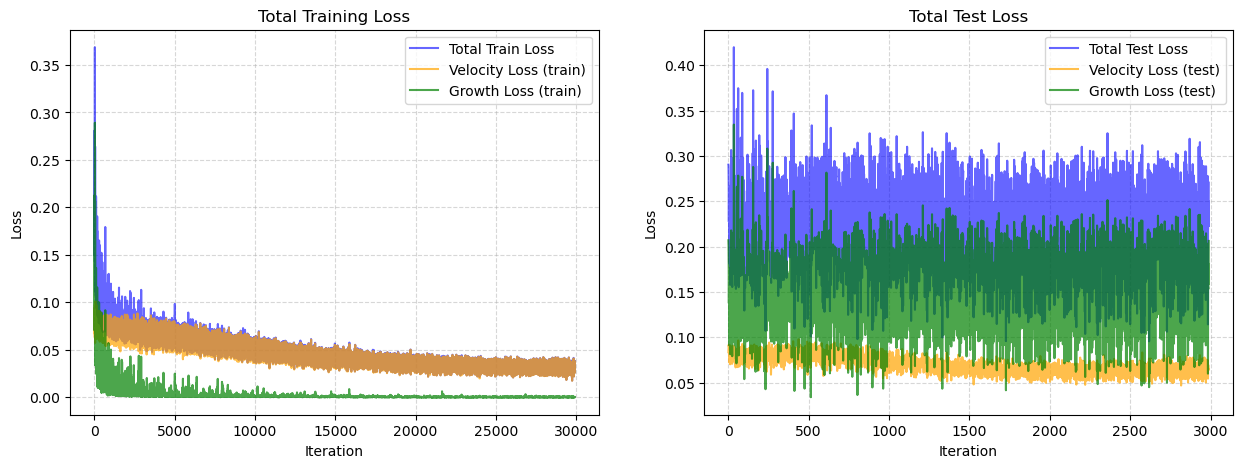

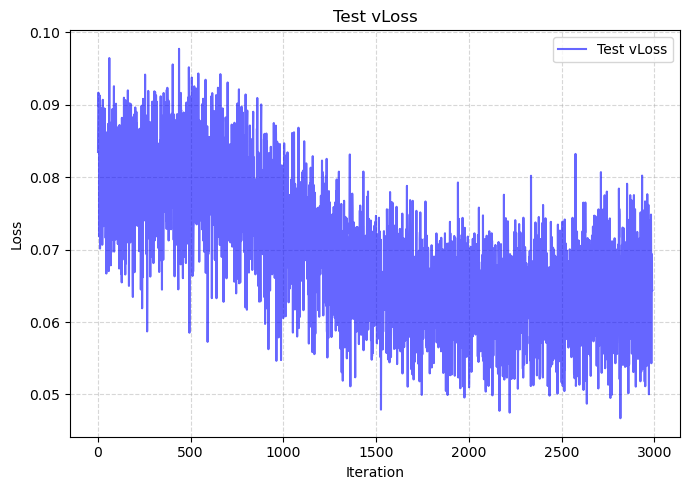

In [16]:
from src.evaluate import draw_loss
load_path = "./results/checkpoints/test_test_epoch_30000.pt"
draw_loss(load_path,eval_interval = 10,cut = 100)

## inference & evalutaion

In [12]:
from src.evaluate import run_batch_inference
# target_genes = ['TADA1', 'MED12', 'ZNF714', 'ZNF286A', 'MAP3K7', 'TGFBR2', 'EPB41L2']
# target_genes = ['CHMP3', 'AKT2', 'SHPRH', 'TMSB4X', 'KLF10', 'TARBP2', 'KDM2B']
target_genes = ['CDCA2', 'DHX36', 'TMSB10', 'KAT2A', 'PHF14', 'KLF10', 'KDM1A']

# target_genes = ['CDCA2', 'DHX36', 'TMSB10']
                
n_particles = 5000
all_indices = np.arange(adata_control.n_obs)
rng = np.random.default_rng(42)
indices = rng.choice(all_indices, n_particles, replace=False) if n_particles < len(all_indices) else all_indices
adata_source = torch.tensor(adata_control.obsm[sample_rep_scaled][indices], dtype=torch.float32, device=device)

results_embedding = run_batch_inference(
    model=model,
    adata_source=adata_source,
    adata_conditions=adata_train,
    target_conditions=target_genes,
    condition_keys = condition_keys,
    embedding_key = condition_rep_keys,
    source_rep = sample_rep_scaled,
    n_steps = 50, # ode step
    device = device,
    random_seed = 42
)

100%|██████████| 7/7 [01:30<00:00, 12.93s/it]


In [13]:
from src.evaluate import batch_reconstruct_pca, batch_reconstruct_scvi, batch_reconstruct_flatvi

# 我们可以reconstruct出原始基因表达
# 这里 m应该咋用呢
if sample_rep == "X_pca":
    results_genes = batch_reconstruct_pca(
        inference_results=results_embedding,  
        ref_adata=adata_control        
    )
elif sample_rep == "X_scVI":
    batch_data = adata_control.obs['_scvi_batch'].values[indices]
    results_genes = batch_reconstruct_scvi(
        inference_results=results_embedding,
        scvi_model=model_ref,  # 传入模型
        target_library_size=1e4, # 输出将被标准化到 10,000 counts
        batch_idx = torch.tensor(adata_control.obs['_scvi_batch'].values[indices], dtype=torch.long, device=device).unsqueeze(1) # 如果希望都投射到第0个batch 可以直接不传或者传None
    )
elif sample_rep =="X_flatvi":
    results_genes = batch_reconstruct_flatvi(
        inference_results=results_embedding,
        flatvi_model=model_ref,
        target_library_size=1e4,
        var_names = adata_control.var_names
    )


  0%|          | 0/7 [00:00<?, ?it/s]/home/nepenthes/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
 14%|█▍        | 1/7 [00:00<00:01,  3.83it/s]/home/nepenthes/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
 29%|██▊       | 2/7 [00:00<00:01,  2.55it/s]/home/nepenthes/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
 43%|████▎     | 3/7 [00:01<00:02,  1.56it/s]/home/nepenthes/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
 57%|█████▋    |

In [14]:
#print(results_embedding)
#print(results_genes)

In [15]:
from src.evaluate.evals import *

In [16]:
# 1. 运行主要评估 (MSE, R2, PCC, Spearman)
df_results = evaluate_all(
    results_genes=results_genes,
    results_embedding=results_embedding,
    adata_train=adata_train,
    adata_control=adata_control,
    pert_key=condition_keys,         # 假设你的 adata_train.obs['condition'] 存储扰动名
    control_label=control_key,         # 这个参数在 evaluate_all 内部主要用于逻辑参考，实际计算用了 adata_control
    embedding_key=sample_rep_scaled # 指定 embedding 存储位置
)

print("评估结果预览：")
print(df_results)

# 2. 运行 PDISC 评估 (区分度指标)
pdisc_scores, pdisc_mean = evaluate_pdisc(
    results_genes=results_genes,
    adata_train=adata_train,
    adata_control=adata_control,
    pert_key=condition_keys
)

print(f"Global PDISC Mean: {pdisc_mean}")



Start evaluating 7 perturbations (Pseudo-bulk mode)...
评估结果预览：
  perturbation  gene_mse  gene_mae  gene_r2_global  gene_pcc_delta  \
0        CDCA2  0.016787  0.071563        0.903547       -0.032968   
1        DHX36  0.021951  0.081662        0.872282       -0.073150   
2       TMSB10  0.017157  0.071807        0.900975        0.112579   
3        KAT2A  0.018196  0.074712        0.893263        0.038984   
4        PHF14  0.017950  0.073834        0.896951       -0.000218   
5        KLF10  0.015634  0.069122        0.909724        0.251313   
6        KDM1A  0.021374  0.081905        0.870424        0.262562   

   gene_spearman_delta  latent_mse  latent_cosine  latent_delta_cosine  
0            -0.038288    1.096129      -0.087695            -0.087697  
1            -0.039546    1.967528      -0.081756            -0.081756  
2             0.097144    1.343485      -0.011892            -0.011893  
3             0.039929    1.404814       0.137390             0.137390  
4          

In [ ]:
from src.evaluate import plot_perturbation_umap
plot_perturbation_umap(
    results_embedding=results_embedding,
    adata_control=adata_control,
    adata_conditions=adata_train, # 或者 adata_test
    target_genes=target_genes,
    control_indices=indices, 
    rep_key=sample_rep_scaled
)

In [ ]:
from src.evaluate import plot_perturbation_umap
plot_perturbation_umap(
    results_embedding=results_embedding,
    adata_control=adata_control,
    adata_conditions=adata_test, # 或者 adata_test
    target_genes=target_genes,
    control_indices=indices, 
    rep_key=sample_rep_scaled
)

In [19]:
if sample_rep_scaled in ["X_scVI", "X_flatvi"]: 
    sc.pp.normalize_total(adata_control, target_sum=1e4)
    sc.pp.normalize_total(adata_train, target_sum=1e4)
    sc.pp.normalize_total(adata_test, target_sum=1e4)


# 可以使用以下函数复原，可以返回去掉batch信息后的归一化count
# 但是会导致返回的不再是一个稀疏矩阵，导致内存爆掉
# 应对方法可能有:只看某些基因等等
# temp = model_ref.get_normalized_expression(
#         adata=adata, 
#         library_size="latent", 
#         n_samples=10,         
#         return_mean=True,
#         transform_batch= ？？ 
#     )

In [ ]:
from src.evaluate import plot_top_degs_violin
for target in target_genes: # ['CDCA2', 'DHX36', 'TMSB10']
    plot_top_degs_violin(
        reconstructed_data=results_genes,
        adata_control=adata_control,
        adata_real=adata_train,
        target_gene=target,
        top_n=4 # 展示 Target + Top 4 下游基因
    )

In [ ]:
from src.evaluate import plot_top_degs_violin
for target in target_genes: # ['CDCA2', 'DHX36', 'TMSB10']
    plot_top_degs_violin(
        reconstructed_data=results_genes,
        adata_control=adata_control,
        adata_real=adata_test,
        target_gene=target,
        top_n=4 # 展示 Target + Top 4 下游基因
    )

=== Mass Statistics for CDCA2 prediction ===
Mean Mass: 0.0433
Max  Mass: 0.0472
Min  Mass: 0.0411
Std  Mass: 0.0009


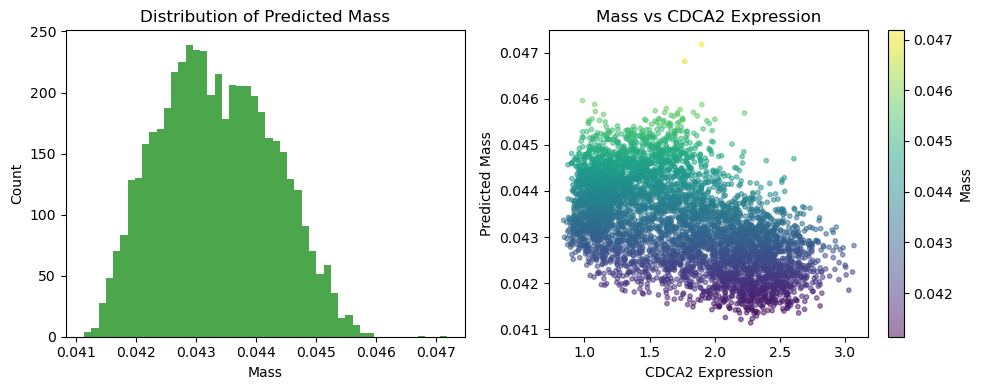

=== Mass Statistics for DHX36 prediction ===
Mean Mass: 0.0351
Max  Mass: 0.0530
Min  Mass: 0.0284
Std  Mass: 0.0031


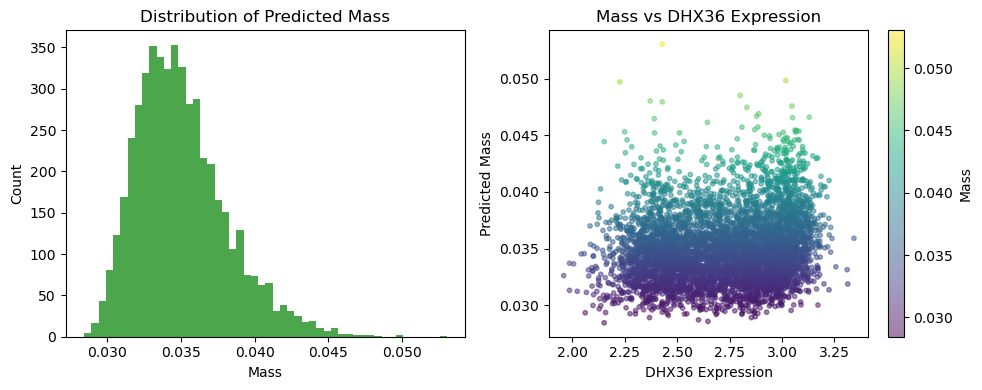

=== Mass Statistics for TMSB10 prediction ===
Mean Mass: 0.0230
Max  Mass: 0.0280
Min  Mass: 0.0209
Std  Mass: 0.0009


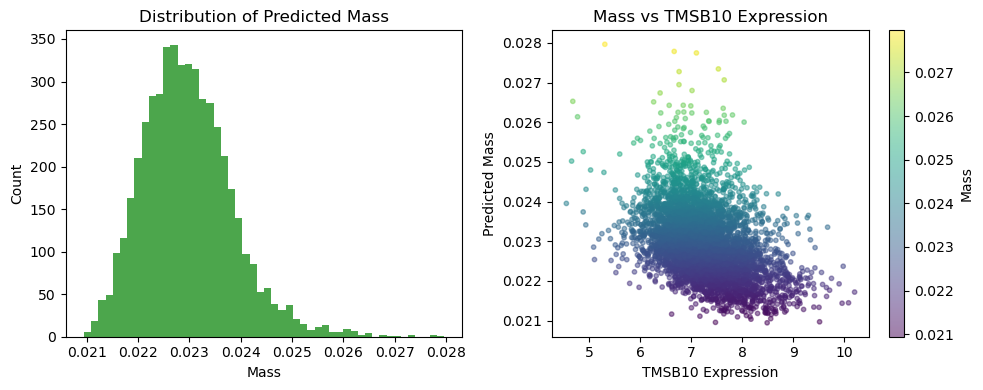

=== Mass Statistics for KAT2A prediction ===
Mean Mass: 0.0525
Max  Mass: 0.0689
Min  Mass: 0.0452
Std  Mass: 0.0032


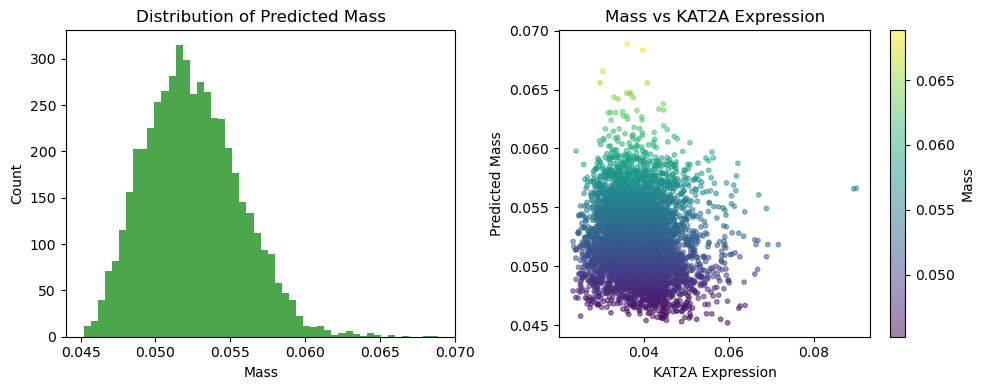

=== Mass Statistics for PHF14 prediction ===
Mean Mass: 0.0236
Max  Mass: 0.0274
Min  Mass: 0.0225
Std  Mass: 0.0005


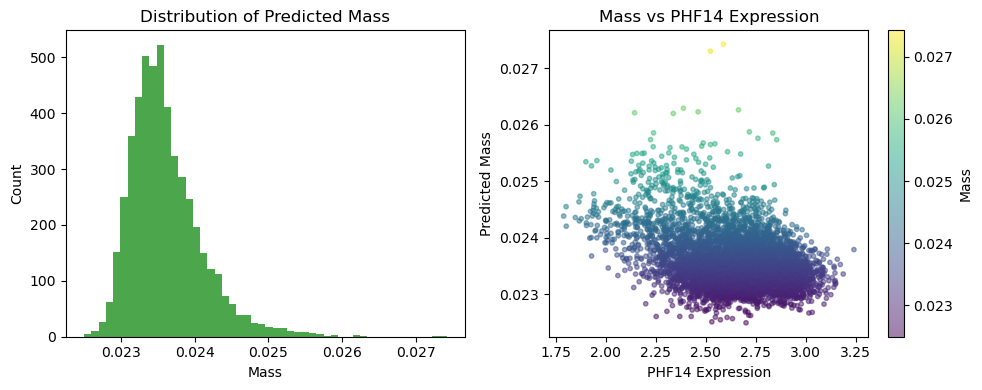

=== Mass Statistics for KLF10 prediction ===
Mean Mass: 0.0484
Max  Mass: 0.0560
Min  Mass: 0.0455
Std  Mass: 0.0017


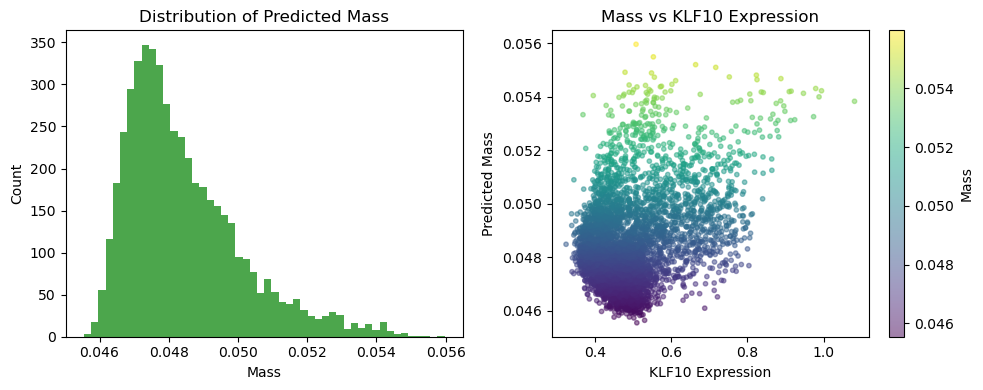

=== Mass Statistics for KDM1A prediction ===
Mean Mass: 0.0095
Max  Mass: 0.0193
Min  Mass: 0.0053
Std  Mass: 0.0021


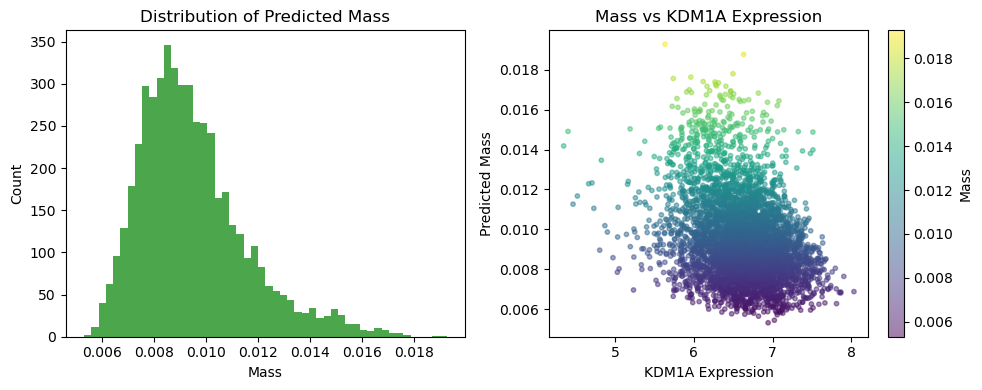

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def diagnose_mass_prediction(pred_adata, gene_name='CDCA2'):
    mass = pred_adata.obs['mass'].values
    expr = pred_adata[:, gene_name].X.flatten() # 或者是 .layers['counts'] 等
    
    # 1. 打印统计数据
    print(f"=== Mass Statistics for {gene_name} prediction ===")
    print(f"Mean Mass: {np.mean(mass):.4f}")
    print(f"Max  Mass: {np.max(mass):.4f}")
    print(f"Min  Mass: {np.min(mass):.4f}")
    print(f"Std  Mass: {np.std(mass):.4f}")
    
    # 2. 绘图：Mass vs Target Gene Expression
    plt.figure(figsize=(10, 4))
    
    # 子图1: Mass 的直方图
    plt.subplot(1, 2, 1)
    plt.hist(mass, bins=50, color='green', alpha=0.7)
    plt.title("Distribution of Predicted Mass")
    plt.xlabel("Mass")
    plt.ylabel("Count")
    
    # 子图2: Mass vs Expression
    plt.subplot(1, 2, 2)
    plt.scatter(expr, mass, alpha=0.5, s=10, c=mass, cmap='viridis')
    plt.title(f"Mass vs {gene_name} Expression")
    plt.xlabel(f"{gene_name} Expression")
    plt.ylabel("Predicted Mass")
    plt.colorbar(label='Mass')
    
    plt.tight_layout()
    plt.show()

# 运行诊断
for gene in target_genes:
    diagnose_mass_prediction(results_genes[gene], gene)